# Devectorisation Check
### DGL 2026 Brain Graph Super-Resolution Challenge

Validates that `MatrixVectorizer.anti_vectorize` correctly reconstructs symmetric brain connectivity matrices from the competition CSV files.

**Checks:** shape, symmetry, zero diagonal, no NaNs/negatives, roundtrip fidelity.

In [11]:
import sys
sys.path.insert(0, "..")   # make utils/ importable from notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from utils.matrix_vectorizer import MatrixVectorizer
from utils.graph_utils import preprocess_data

mv = MatrixVectorizer()
print("Imports OK")

Imports OK


## 1 — Spec sanity check (4×4 example from the competition PDF)

In [12]:
A = np.array([[0,1,2,4],
              [1,0,3,5],
              [2,3,0,6],
              [4,5,6,0]], dtype=float)

x  = mv.vectorize(A)
A2 = mv.anti_vectorize(x, 4)

print(f"Vector       : {x}")
print(f"Expected     : [1. 2. 3. 4. 5. 6.]")
print(f"Match        : {np.array_equal(x, [1,2,3,4,5,6])}")
print(f"Roundtrip OK : {np.allclose(A, A2)}")

Vector       : [1. 2. 3. 4. 5. 6.]
Expected     : [1. 2. 3. 4. 5. 6.]
Match        : True
Roundtrip OK : True


## 2 — Load & preprocess real data

In [13]:
lr_raw = pd.read_csv("../data/lr_train.csv", header=0).values.astype(np.float32)
hr_raw = pd.read_csv("../data/hr_train.csv", header=0).values.astype(np.float32)

lr = preprocess_data(lr_raw.copy())
hr = preprocess_data(hr_raw.copy())

print(f"LR data  : {lr.shape}   NaNs={np.isnan(lr).sum()}  negs={(lr < 0).sum()}")
print(f"HR data  : {hr.shape}   NaNs={np.isnan(hr).sum()}  negs={(hr < 0).sum()}")
print(f"LR range : {lr.min():.4f} – {lr.max():.4f}")
print(f"HR range : {hr.min():.4f} – {hr.max():.4f}")

LR data  : (167, 12720)   NaNs=0  negs=0
HR data  : (167, 35778)   NaNs=0  negs=0
LR range : 0.0000 – 0.9990
HR range : 0.0000 – 0.9999


## 3 — Devectorize subject 0 and verify properties

In [14]:
SUBJECT = 0

lr_adj = mv.anti_vectorize(lr[SUBJECT], 160)
hr_adj = mv.anti_vectorize(hr[SUBJECT], 268)

checks = {
    "LR shape"        : lr_adj.shape == (160, 160),
    "HR shape"        : hr_adj.shape == (268, 268),
    "LR symmetric"    : np.allclose(lr_adj, lr_adj.T),
    "HR symmetric"    : np.allclose(hr_adj, hr_adj.T),
    "LR diag = 0"     : np.allclose(np.diag(lr_adj), 0),
    "HR diag = 0"     : np.allclose(np.diag(hr_adj), 0),
    "LR no negatives" : (lr_adj >= 0).all(),
    "HR no negatives" : (hr_adj >= 0).all(),
    "LR roundtrip"    : np.allclose(mv.vectorize(lr_adj), lr[SUBJECT]),
    "HR roundtrip"    : np.allclose(mv.vectorize(hr_adj), hr[SUBJECT]),
}

for label, ok in checks.items():
    print(f"  {'✓' if ok else '✗'}  {label}")

print(f"\nLR non-zero edges : {(lr_adj > 0).sum():,}")
print(f"HR non-zero edges : {(hr_adj > 0).sum():,}")
print(f"LR weight range   : {lr_adj.min():.4f} – {lr_adj.max():.4f}")
print(f"HR weight range   : {hr_adj.min():.4f} – {hr_adj.max():.4f}")

  ✓  LR shape
  ✓  HR shape
  ✓  LR symmetric
  ✓  HR symmetric
  ✓  LR diag = 0
  ✓  HR diag = 0
  ✓  LR no negatives
  ✓  HR no negatives
  ✓  LR roundtrip
  ✓  HR roundtrip

LR non-zero edges : 18,318
HR non-zero edges : 59,754
LR weight range   : 0.0000 – 0.9151
HR weight range   : 0.0000 – 0.9647


## 4b — What does *wrong* devectorisation look like?

Three common mistakes applied to the **real LR and HR data**, visualised against the correct result.

A correct brain connectivity matrix must satisfy:
- **Symmetric** (`A == Aᵀ`) — identical above and below the diagonal
- **Zero diagonal** — no self-connections  
- **Block structure preserved** — anatomically related regions cluster together; scrambled ordering destroys this

The bottom row shows the absolute difference from the correct matrix. Any non-zero region is a bug.

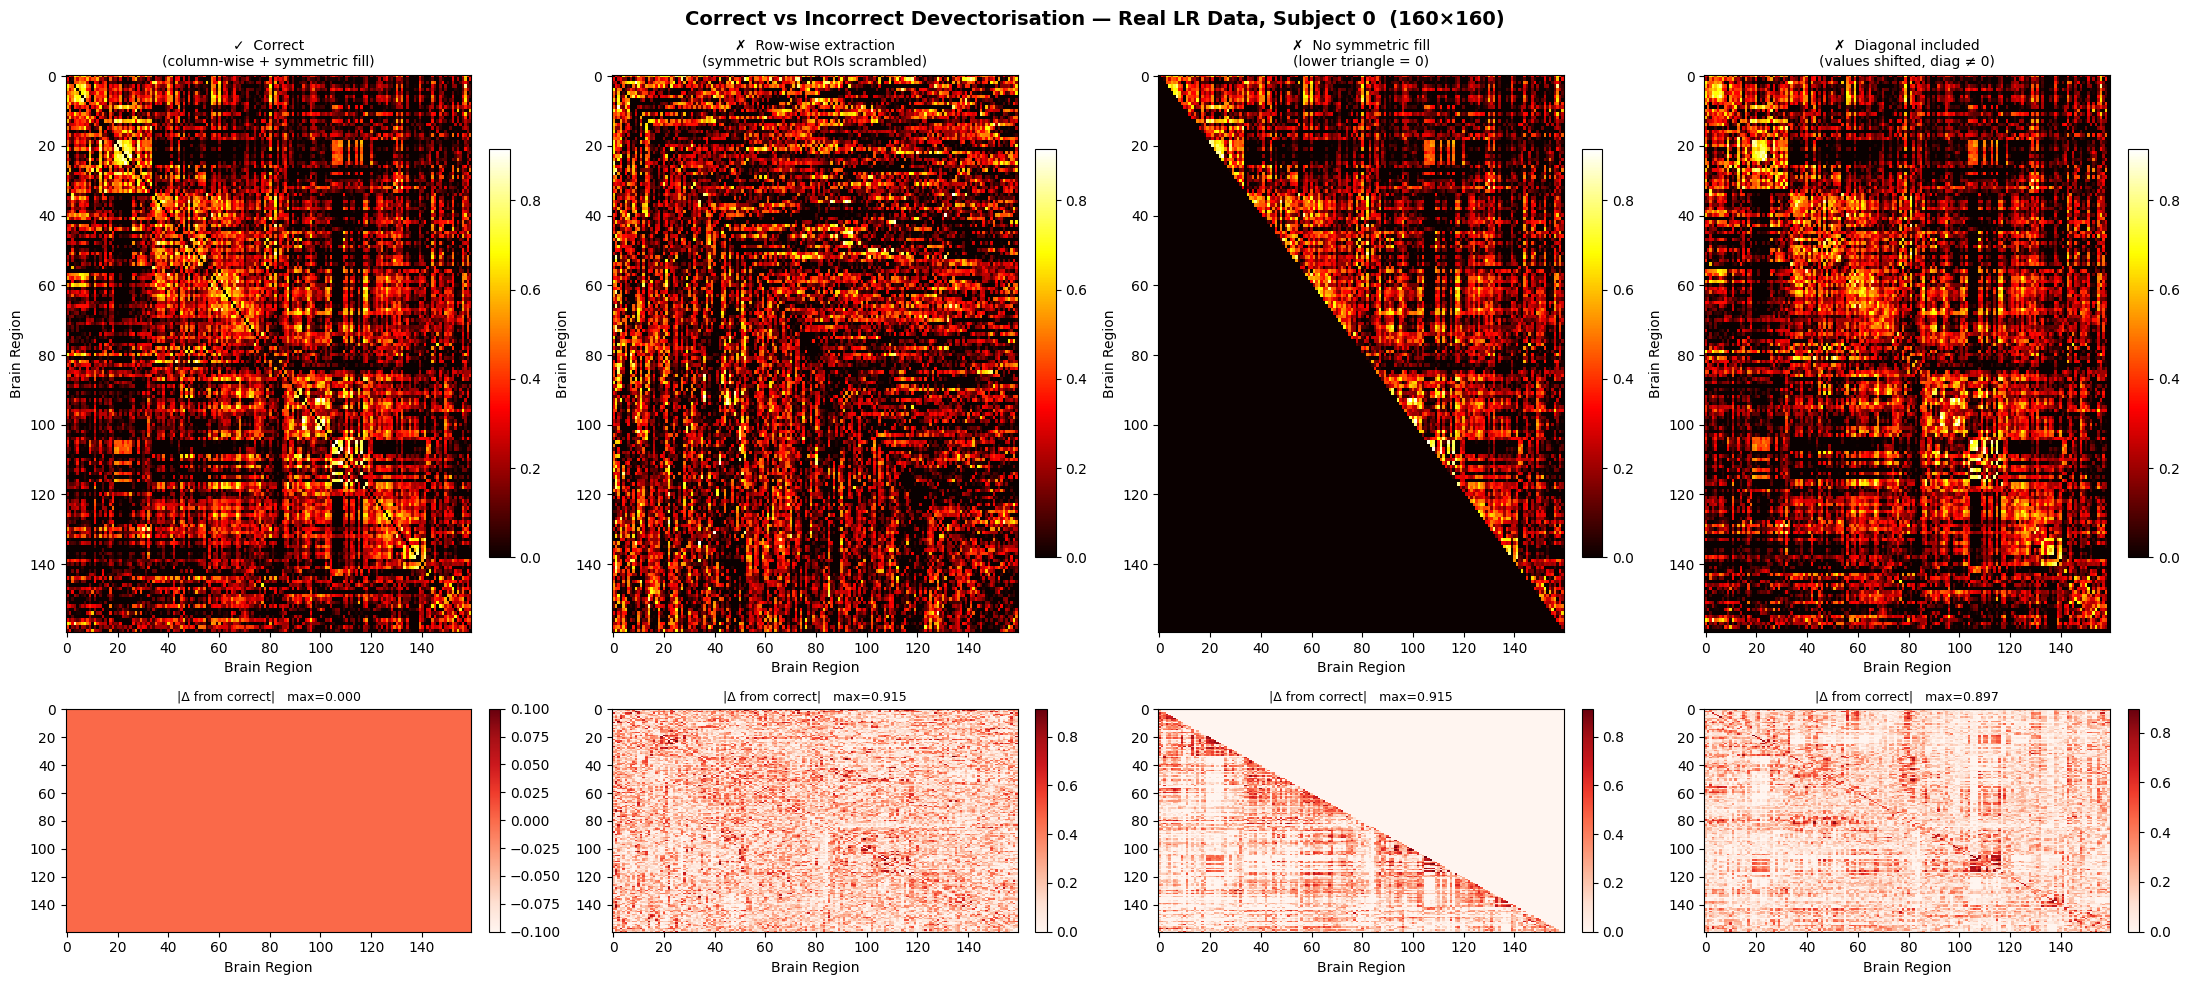


Method                                         Symmetric    Diag=0      Max|Δ|   Non-zero edges
───────────────────────────────────────────────────────────────────────────────────────────────
✓  Correct (column-wise + symmetric fill)              ✓         ✓      0.0000           18,318
✗  Row-wise extraction (symmetric but ROIs scrambled)          ✓         ✓      0.9151           18,318
✗  No symmetric fill (lower triangle = 0)              ✗         ✓      0.9151            9,159
✗  Diagonal included (values shifted, diag ≠ 0)          ✓         ✗      0.8967           18,171


In [15]:
# ── Wrong devectorisation implementations ────────────────────────────────────

def wrong_rowwise(vector, n):
    """
    WRONG: row-major fill (numpy triu_indices default).
    numpy extracts upper triangle row-by-row: (0,1),(0,2),(0,3)...
    The spec requires column-by-column:       (0,1),(0,2),(1,2),(0,3)...
    Result: symmetric, but every edge value is assigned to the wrong pair of ROIs.
    The block structure that reflects brain anatomy is completely scrambled.
    """
    mat = np.zeros((n, n))
    rows, cols = np.triu_indices(n, k=1)   # row-major order
    mat[rows, cols] = vector
    mat[cols, rows] = vector               # symmetric fill
    return mat


def wrong_upper_only(vector, n):
    """
    WRONG: column-wise order is correct, but the lower triangle is never filled.
    Result: visually asymmetric — lower half is all zeros.
    Immediately caught by A == A^T check.
    """
    mat = np.zeros((n, n))
    idx = 0
    for col in range(n):
        for row in range(n):
            if row < col:
                mat[row, col] = vector[idx]   # no mirror write
                idx += 1
    return mat


def wrong_with_diagonal(vector, n):
    """
    WRONG: uses row <= col instead of row < col, treating diagonal as an edge.
    Result: every value is shifted by one position — real edge weights land on the
    wrong nodes, and non-zero values appear on the diagonal.
    Immediately caught by diag(A) == 0 check.
    """
    mat = np.zeros((n, n))
    idx = 0
    for col in range(n):
        for row in range(n):
            if row <= col and idx < len(vector):   # <= includes diagonal
                mat[row, col] = vector[idx]
                mat[col, row] = vector[idx]
                idx += 1
    return mat


# ── Compute the four matrices from real LR data (Subject 0) ──────────────────
correct     = lr_adj                                        # already computed in Cell 7
bad_rowwise = wrong_rowwise(lr[SUBJECT], 160)
bad_upper   = wrong_upper_only(lr[SUBJECT], 160)
bad_diag    = wrong_with_diagonal(lr[SUBJECT], 160)

methods = [
    ("✓  Correct\n(column-wise + symmetric fill)",          correct),
    ("✗  Row-wise extraction\n(symmetric but ROIs scrambled)", bad_rowwise),
    ("✗  No symmetric fill\n(lower triangle = 0)",          bad_upper),
    ("✗  Diagonal included\n(values shifted, diag ≠ 0)",   bad_diag),
]

vmax = correct.max()

fig, axes = plt.subplots(2, 4, figsize=(22, 10),
                         gridspec_kw={"height_ratios": [3, 1.2]})
fig.suptitle(
    "Correct vs Incorrect Devectorisation — Real LR Data, Subject 0  (160×160)",
    fontsize=14, fontweight="bold"
)

for i, (title, mat) in enumerate(methods):
    # Top row: matrix heatmap
    ax = axes[0, i]
    im = ax.imshow(mat, cmap="hot", aspect="auto", interpolation="nearest",
                   vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Brain Region")
    ax.set_ylabel("Brain Region")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Bottom row: absolute difference from correct
    ax2 = axes[1, i]
    diff = np.abs(mat - correct)
    im2  = ax2.imshow(diff, cmap="Reds", aspect="auto", interpolation="nearest")
    ax2.set_title(f"|Δ from correct|   max={diff.max():.3f}", fontsize=9)
    ax2.set_xlabel("Brain Region")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── Diagnostic table ──────────────────────────────────────────────────────────
print(f"\n{'Method':<45} {'Symmetric':>10}  {'Diag=0':>8}  {'Max|Δ|':>10}  {'Non-zero edges':>15}")
print("─" * 95)
for title, mat in methods:
    label     = title.replace("\n", " ")
    symmetric = np.allclose(mat, mat.T)
    diag_zero = np.allclose(np.diag(mat), 0)
    max_diff  = np.abs(mat - correct).max()
    nonzero   = (mat > 0).sum()
    sym_str   = "✓" if symmetric else "✗"
    diag_str  = "✓" if diag_zero  else "✗"
    print(f"{label:<45} {sym_str:>10}  {diag_str:>8}  {max_diff:>10.4f}  {nonzero:>15,}")

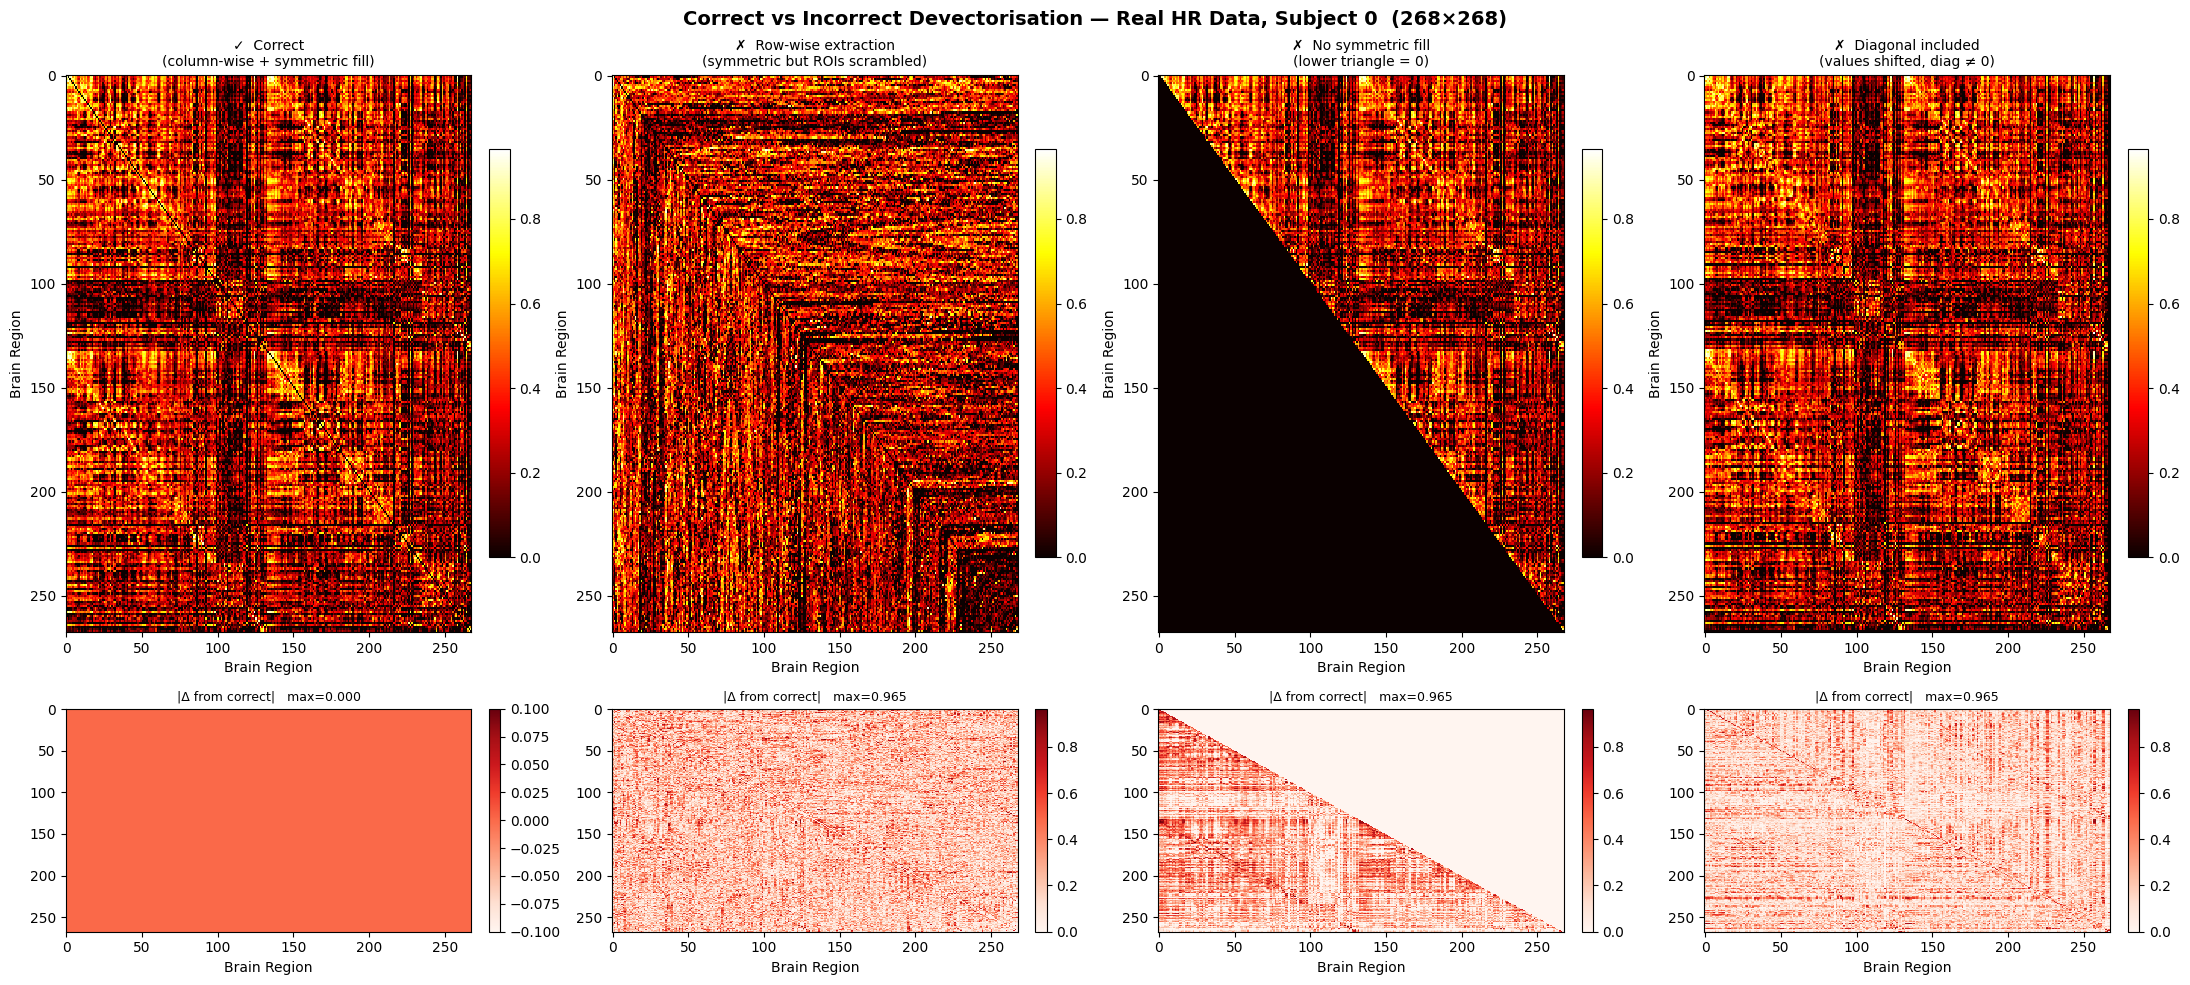


Method                                         Symmetric    Diag=0      Max|Δ|   Non-zero edges
───────────────────────────────────────────────────────────────────────────────────────────────
✓  Correct (column-wise + symmetric fill)              ✓         ✓      0.0000           59,754
✗  Row-wise extraction (symmetric but ROIs scrambled)          ✓         ✓      0.9647           59,754
✗  No symmetric fill (lower triangle = 0)              ✗         ✓      0.9647           29,877
✗  Diagonal included (values shifted, diag ≠ 0)          ✓         ✗      0.9647           59,514


In [16]:
# ── Same comparison on HR data (268×268) ─────────────────────────────────────
hr_correct     = hr_adj
hr_bad_rowwise = wrong_rowwise(hr[SUBJECT], 268)
hr_bad_upper   = wrong_upper_only(hr[SUBJECT], 268)
hr_bad_diag    = wrong_with_diagonal(hr[SUBJECT], 268)

hr_methods = [
    ("✓  Correct\n(column-wise + symmetric fill)",             hr_correct),
    ("✗  Row-wise extraction\n(symmetric but ROIs scrambled)", hr_bad_rowwise),
    ("✗  No symmetric fill\n(lower triangle = 0)",             hr_bad_upper),
    ("✗  Diagonal included\n(values shifted, diag ≠ 0)",      hr_bad_diag),
]

hr_vmax = hr_correct.max()

fig, axes = plt.subplots(2, 4, figsize=(22, 10),
                         gridspec_kw={"height_ratios": [3, 1.2]})
fig.suptitle(
    "Correct vs Incorrect Devectorisation — Real HR Data, Subject 0  (268×268)",
    fontsize=14, fontweight="bold"
)

for i, (title, mat) in enumerate(hr_methods):
    ax = axes[0, i]
    im = ax.imshow(mat, cmap="hot", aspect="auto", interpolation="nearest",
                   vmin=0, vmax=hr_vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Brain Region")
    ax.set_ylabel("Brain Region")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax2 = axes[1, i]
    diff = np.abs(mat - hr_correct)
    im2  = ax2.imshow(diff, cmap="Reds", aspect="auto", interpolation="nearest")
    ax2.set_title(f"|Δ from correct|   max={diff.max():.3f}", fontsize=9)
    ax2.set_xlabel("Brain Region")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"\n{'Method':<45} {'Symmetric':>10}  {'Diag=0':>8}  {'Max|Δ|':>10}  {'Non-zero edges':>15}")
print("─" * 95)
for title, mat in hr_methods:
    label    = title.replace("\n", " ")
    sym_str  = "✓" if np.allclose(mat, mat.T)     else "✗"
    diag_str = "✓" if np.allclose(np.diag(mat), 0) else "✗"
    max_diff = np.abs(mat - hr_correct).max()
    nonzero  = (mat > 0).sum()
    print(f"{label:<45} {sym_str:>10}  {diag_str:>8}  {max_diff:>10.4f}  {nonzero:>15,}")

## 4 — Adjacency matrix heatmaps (Subject 0)

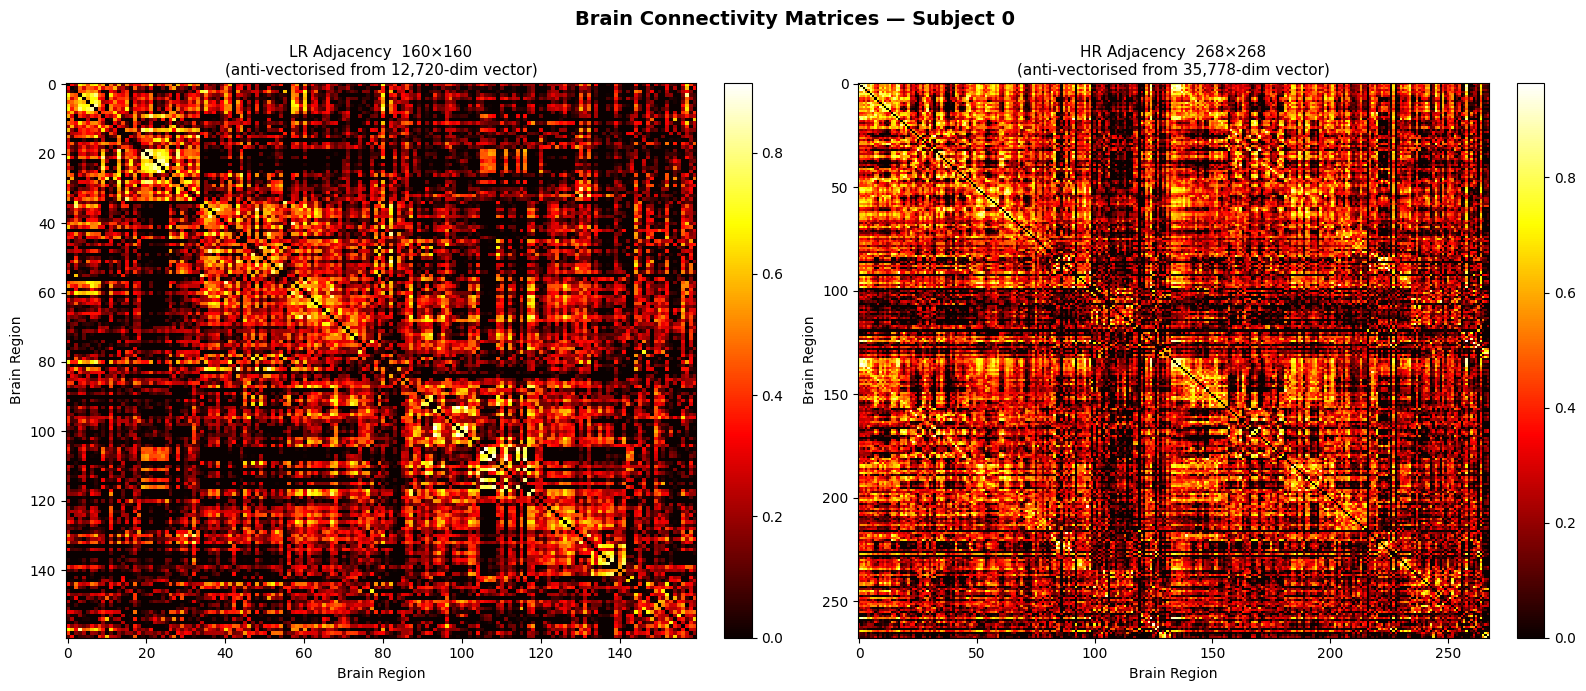

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle(f"Brain Connectivity Matrices — Subject {SUBJECT}",
             fontsize=14, fontweight='bold')

im0 = axes[0].imshow(lr_adj, cmap='hot', aspect='auto', interpolation='nearest')
axes[0].set_title("LR Adjacency  160×160\n(anti-vectorised from 12,720-dim vector)", fontsize=11)
axes[0].set_xlabel("Brain Region"); axes[0].set_ylabel("Brain Region")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(hr_adj, cmap='hot', aspect='auto', interpolation='nearest')
axes[1].set_title("HR Adjacency  268×268\n(anti-vectorised from 35,778-dim vector)", fontsize=11)
axes[1].set_xlabel("Brain Region"); axes[1].set_ylabel("Brain Region")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 5 — Edge weight distributions

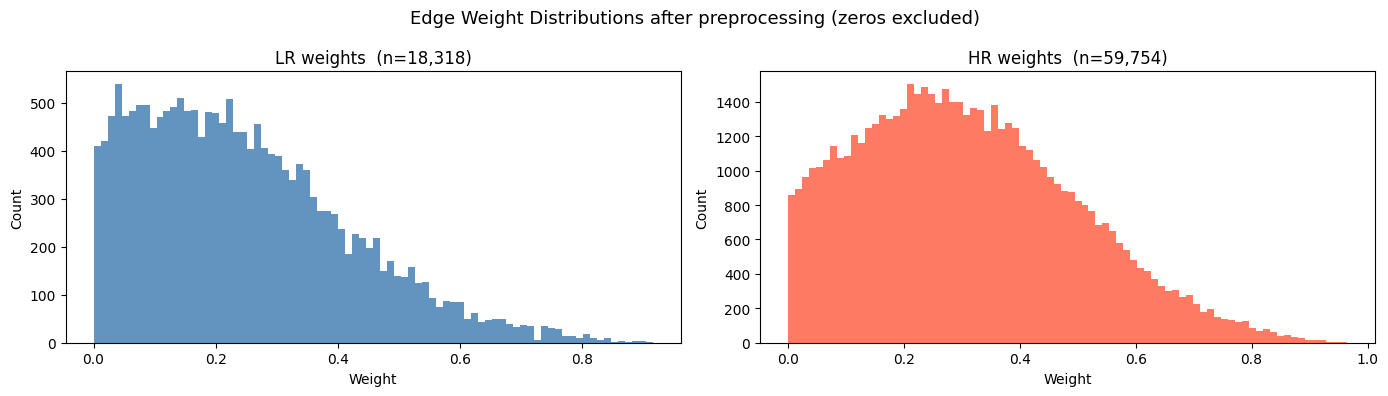

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Edge Weight Distributions after preprocessing (zeros excluded)", fontsize=13)

lr_vals = lr_adj[lr_adj > 0].flatten()
hr_vals = hr_adj[hr_adj > 0].flatten()

axes[0].hist(lr_vals, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title(f"LR weights  (n={len(lr_vals):,})")
axes[0].set_xlabel("Weight"); axes[0].set_ylabel("Count")

axes[1].hist(hr_vals, bins=80, color='tomato', edgecolor='none', alpha=0.85)
axes[1].set_title(f"HR weights  (n={len(hr_vals):,})")
axes[1].set_xlabel("Weight"); axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 6 — Compare LR vs HR across 3 subjects

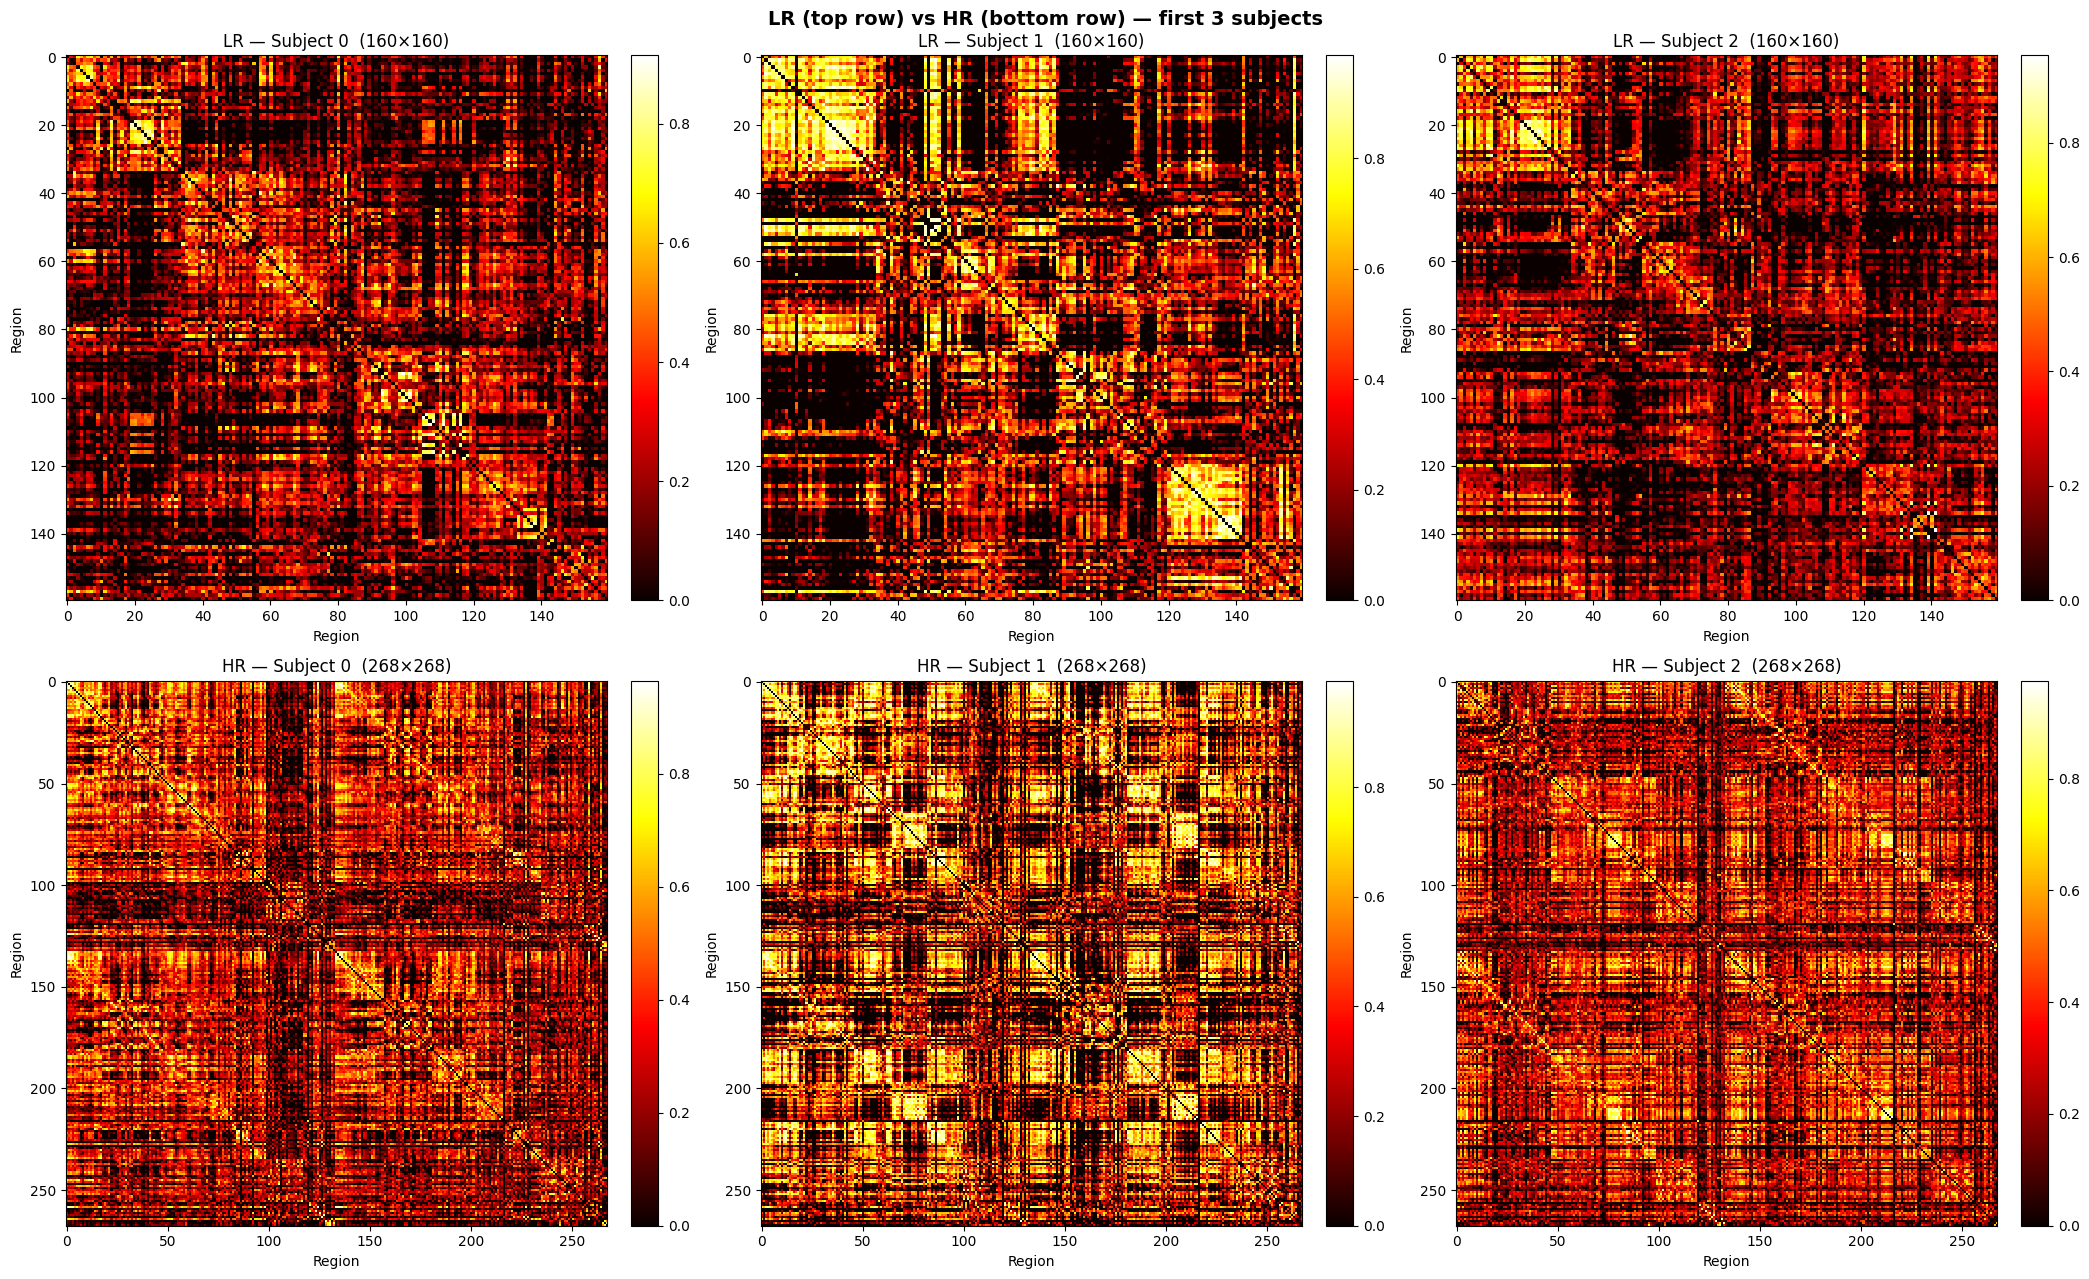

In [19]:
N_SUBJECTS = 3

fig, axes = plt.subplots(2, N_SUBJECTS, figsize=(7 * N_SUBJECTS, 13))
fig.suptitle("LR (top row) vs HR (bottom row) — first 3 subjects",
             fontsize=14, fontweight='bold')

for i in range(N_SUBJECTS):
    lr_i = mv.anti_vectorize(lr[i], 160)
    hr_i = mv.anti_vectorize(hr[i], 268)

    im_lr = axes[0, i].imshow(lr_i, cmap='hot', aspect='auto', interpolation='nearest')
    axes[0, i].set_title(f"LR — Subject {i}  (160×160)")
    axes[0, i].set_xlabel("Region"); axes[0, i].set_ylabel("Region")
    plt.colorbar(im_lr, ax=axes[0, i], fraction=0.046, pad=0.04)

    im_hr = axes[1, i].imshow(hr_i, cmap='hot', aspect='auto', interpolation='nearest')
    axes[1, i].set_title(f"HR — Subject {i}  (268×268)")
    axes[1, i].set_xlabel("Region"); axes[1, i].set_ylabel("Region")
    plt.colorbar(im_hr, ax=axes[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 7 — Cross-subject consistency: mean & std connectivity matrices

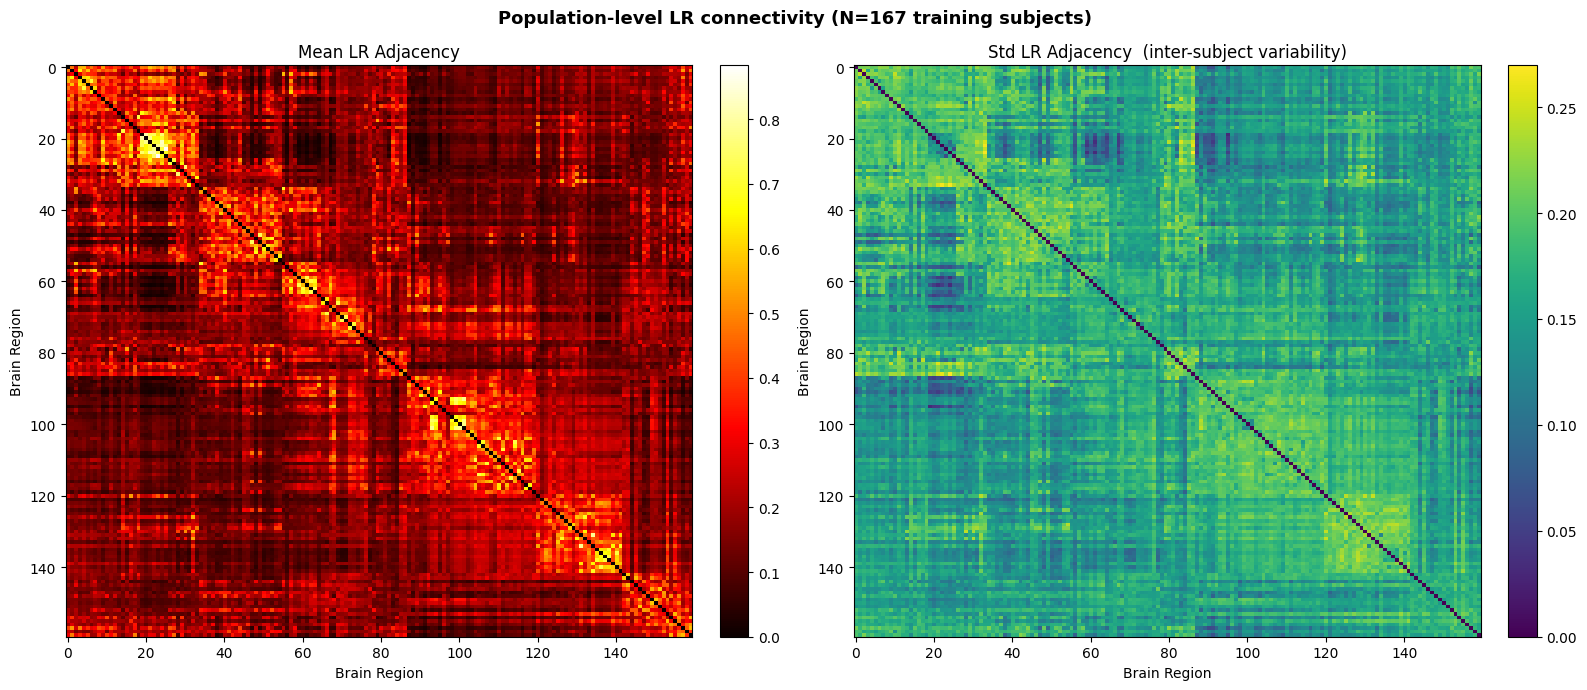

Population mean edge weight : 0.1981
Population std  edge weight : 0.1624


In [20]:
# Build population-level LR mean/std adjacency across all 167 training subjects
all_lr = np.stack([mv.anti_vectorize(lr[i], 160) for i in range(len(lr))], axis=0)

mean_adj = all_lr.mean(axis=0)
std_adj  = all_lr.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Population-level LR connectivity (N=167 training subjects)",
             fontsize=13, fontweight='bold')

im0 = axes[0].imshow(mean_adj, cmap='hot', aspect='auto', interpolation='nearest')
axes[0].set_title("Mean LR Adjacency")
axes[0].set_xlabel("Brain Region"); axes[0].set_ylabel("Brain Region")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(std_adj, cmap='viridis', aspect='auto', interpolation='nearest')
axes[1].set_title("Std LR Adjacency  (inter-subject variability)")
axes[1].set_xlabel("Brain Region"); axes[1].set_ylabel("Brain Region")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print(f"Population mean edge weight : {mean_adj[mean_adj > 0].mean():.4f}")
print(f"Population std  edge weight : {std_adj[std_adj > 0].mean():.4f}")

## 4b — What does *wrong* devectorisation look like?

Three common mistakes, visualised against the correct result.  
A correct brain connectivity matrix must be:
- **Symmetric** (`A == Aᵀ`) — flipping across the diagonal should be identical
- **Zero diagonal** — no self-connections
- **Block structure preserved** — anatomically close regions cluster together

Any deviation from these is a bug.

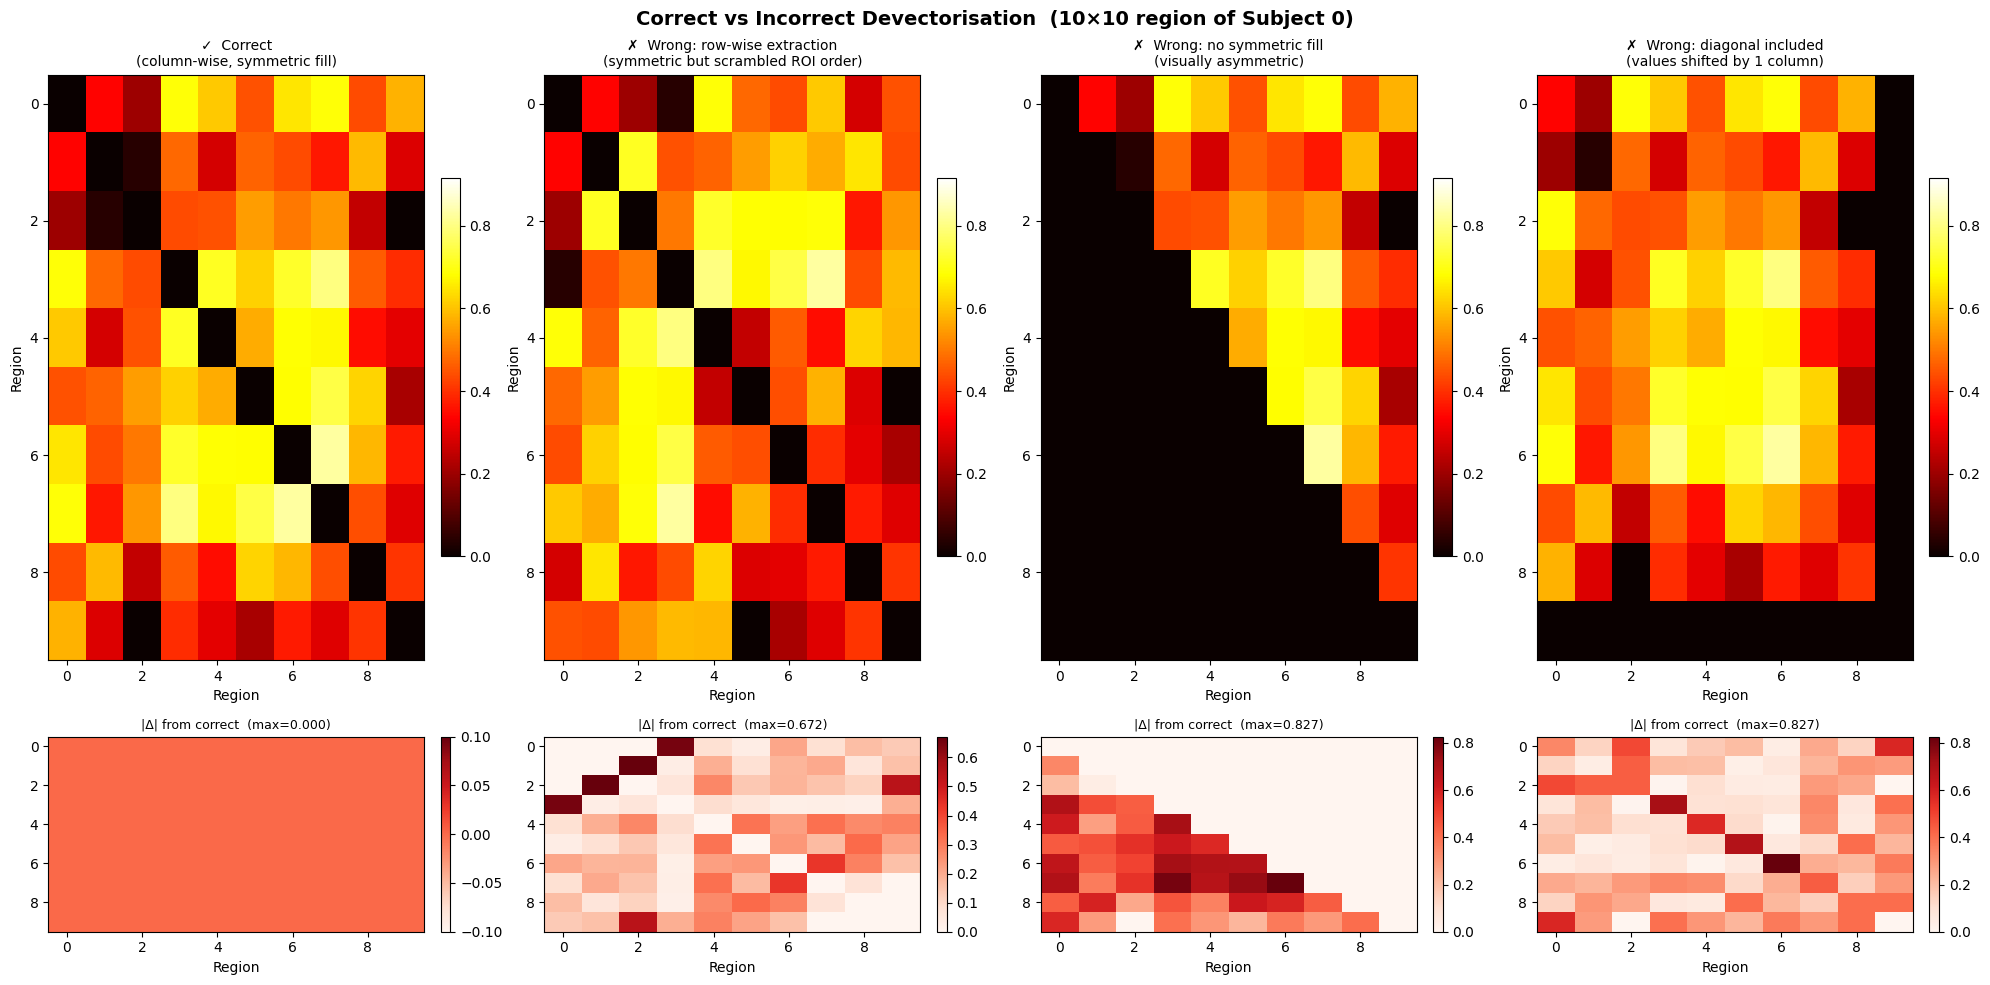

Method                               Symmetric    Diag=0      Max|Δ|
----------------------------------------------------------------------
✓  Correct                                True      True      0.0000
✗  Wrong: row-wise extraction             True      True      0.6717
✗  Wrong: no symmetric fill              False      True      0.8266
✗  Wrong: diagonal included               True     False      0.8266


In [21]:
# ── helpers for the three wrong approaches ──────────────────────────────────

def wrong_rowwise(vector, n):
    """Row-major fill (numpy default triu_indices order) — symmetric but scrambled."""
    mat = np.zeros((n, n))
    # numpy extracts upper triangle row by row: (0,1),(0,2),...(0,n-1),(1,2),...
    # Our spec extracts column by column: (0,1),(0,2),(1,2),(0,3),(1,3),(2,3),...
    # Filling column-wise positions with row-wise values swaps ROI assignments.
    rows, cols = np.triu_indices(n, k=1)          # row-major index order
    mat[rows, cols] = vector
    mat[cols, rows] = vector                       # symmetrise
    return mat

def wrong_upper_only(vector, n):
    """Fills only the upper triangle — visually asymmetric."""
    mat = np.zeros((n, n))
    idx = 0
    for col in range(n):
        for row in range(n):
            if row < col:
                mat[row, col] = vector[idx]       # no mirror fill
                idx += 1
    return mat

def wrong_with_diagonal(vector, n):
    """Treats the first element of each column as a diagonal value — shifts all edges."""
    mat = np.zeros((n, n))
    idx = 0
    for col in range(n):
        for row in range(n):
            if row <= col:                        # <= instead of <
                mat[row, col] = vector[idx]
                mat[col, row] = vector[idx]
                idx += 1
                if idx >= len(vector):
                    break
        if idx >= len(vector):
            break
    return mat

# ── use a small 10×10 sub-region so individual cells are visible ─────────────
N = 10
sub_vec  = mv.vectorize(lr_adj[:N, :N])           # correct vector from top-left block

correct       = mv.anti_vectorize(sub_vec, N)
bad_rowwise   = wrong_rowwise(sub_vec, N)
bad_upper     = wrong_upper_only(sub_vec, N)
bad_diag      = wrong_with_diagonal(sub_vec[:N*(N+1)//2], N)  # include diag length

# ── side-by-side plot ────────────────────────────────────────────────────────
titles = [
    "✓  Correct\n(column-wise, symmetric fill)",
    "✗  Wrong: row-wise extraction\n(symmetric but scrambled ROI order)",
    "✗  Wrong: no symmetric fill\n(visually asymmetric)",
    "✗  Wrong: diagonal included\n(values shifted by 1 column)",
]
mats   = [correct, bad_rowwise, bad_upper, bad_diag]

fig, axes = plt.subplots(2, 4, figsize=(20, 10),
                         gridspec_kw={"height_ratios": [3, 1]})
fig.suptitle("Correct vs Incorrect Devectorisation  (10×10 region of Subject 0)",
             fontsize=14, fontweight='bold')

for i, (mat, title) in enumerate(zip(mats, titles)):
    ax = axes[0, i]
    im = ax.imshow(mat, cmap='hot', aspect='auto', interpolation='nearest',
                   vmin=0, vmax=lr_adj.max())
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Region"); ax.set_ylabel("Region")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # Difference from correct in bottom row
    ax2 = axes[1, i]
    diff = np.abs(mat - correct)
    im2  = ax2.imshow(diff, cmap='Reds', aspect='auto', interpolation='nearest')
    ax2.set_title(f"|Δ| from correct  (max={diff.max():.3f})", fontsize=9)
    ax2.set_xlabel("Region")
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# ── symmetry and diagonal diagnostics ────────────────────────────────────────
print(f"{'Method':<35} {'Symmetric':>10}  {'Diag=0':>8}  {'Max|Δ|':>10}")
print("-" * 70)
for mat, title in zip(mats, titles):
    label     = title.split('\n')[0]
    symmetric = np.allclose(mat, mat.T)
    diag_zero = np.allclose(np.diag(mat), 0)
    max_diff  = np.abs(mat - correct).max()
    print(f"{label:<35} {str(symmetric):>10}  {str(diag_zero):>8}  {max_diff:>10.4f}")